# Behavioral searchlight RSA: pleasant-only and unpleasant-only (FDR q = 0.01)

This notebook runs two separate within-category behavioral-RDM analyses:

1. **20 pleasant conditions**: original conditions 0–19.
2. **20 unpleasant conditions**: original conditions 40–59.

For each case, subject-level searchlight/behavioral-RDM Spearman correlations are Fisher-z transformed. A voxelwise one-sample t-test across 20 subjects is then Benjamini–Hochberg FDR-corrected at `q = 0.01`. Saved NIfTI images contain signed t-values only at FDR-significant searchlight centers; all other voxels are zero.

Long-running subject-level results are cached under `outputs/searchlight_results/SS`.

In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from IPython.display import display
from nilearn import plotting
from nilearn.image import new_img_like
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.util.searchlight import (
    evaluate_models_searchlight,
    get_searchlight_RDMs,
    get_volume_searchlight,
)
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
from tqdm.auto import tqdm

PROJECT_DIR = Path(r"\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight")
DATA_DIR = PROJECT_DIR.parent / "IAPS_fMRI_RSA"
BEHAVIORAL_DIR = PROJECT_DIR.parent / "IAPS_behavioral_RDM"
SCORE_DIR = PROJECT_DIR / "outputs" / "searchlight_results" / "SS"
MAP_DIR = PROJECT_DIR / "outputs" / "tBrainmap" / "SS"
SCORE_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

SEARCHLIGHT_RADIUS = 5
MASK_THRESHOLD = 0.5
N_JOBS = 6
N_SUBJECTS = 20
FDR_ALPHA = 0.01
FORCE_RECOMPUTE = False

print(f"Project: {PROJECT_DIR}")
print(f"Maps will be saved in: {MAP_DIR}")

Project: \\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight
Maps will be saved in: \\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS


C:\Users\simona.sartan\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and validate the shared 60-condition inputs

In [2]:
mask = np.load(PROJECT_DIR / "mask.npy")
allsub_avg = np.load(PROJECT_DIR / "allsub_avg.npy", mmap_mode="r")
behavioral_rdm_60 = pd.read_csv(
    BEHAVIORAL_DIR / "rdm_behavioral_normed.csv", index_col=0
).to_numpy(dtype=float)
template_img = nib.load(DATA_DIR / "fMRI_singletrial_betas" / "nifti" / "Nt1.img")

assert mask.shape == (53, 63, 46), f"Unexpected mask shape: {mask.shape}"
assert allsub_avg.shape == (N_SUBJECTS, 60, int(np.prod(mask.shape))), (
    f"Unexpected subject-data shape: {allsub_avg.shape}"
)
assert behavioral_rdm_60.shape == (60, 60), (
    f"Unexpected behavioral RDM shape: {behavioral_rdm_60.shape}"
)
assert np.allclose(behavioral_rdm_60, behavioral_rdm_60.T, equal_nan=True), (
    "Behavioral RDM is not symmetric."
)

# Original condition order: 20 pleasant, 20 neutral, 20 unpleasant.
CASE_INDICES = {
    "pleasant_20": np.arange(0, 20),
    "unpleasant_20": np.arange(40, 60),
}
CASE_RDMS = {
    case_name: behavioral_rdm_60[np.ix_(indices, indices)]
    for case_name, indices in CASE_INDICES.items()
}

for case_name, indices in CASE_INDICES.items():
    print(case_name, "conditions:", indices.tolist())
    print("RDM shape:", CASE_RDMS[case_name].shape)

pleasant_20 conditions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
RDM shape: (20, 20)
unpleasant_20 conditions: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
RDM shape: (20, 20)


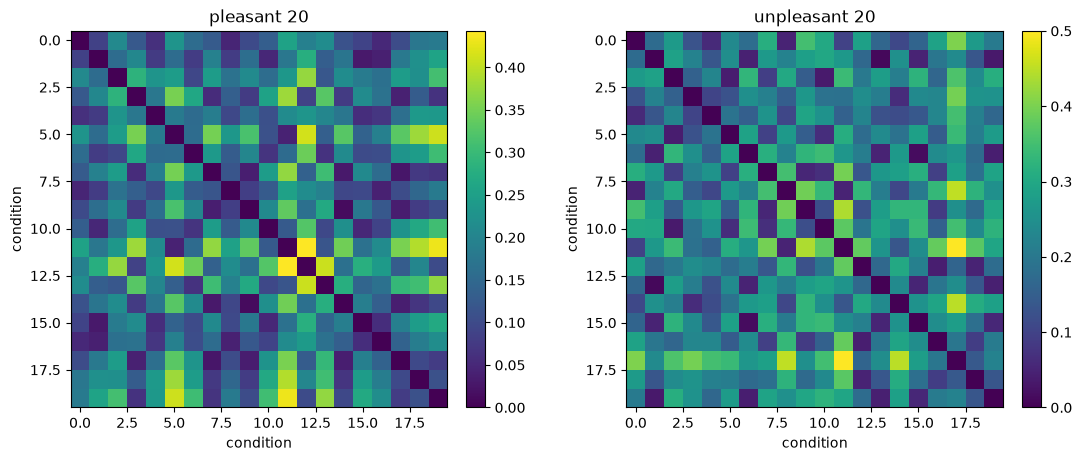

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (case_name, rdm) in zip(axes, CASE_RDMS.items()):
    image = ax.imshow(rdm, cmap="viridis")
    ax.set_title(case_name.replace("_", " "))
    ax.set_xlabel("condition")
    ax.set_ylabel("condition")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Define the radius-5 searchlight and reusable analysis functions

In [4]:
centers, neighbors = get_volume_searchlight(
    mask, radius=SEARCHLIGHT_RADIUS, threshold=MASK_THRESHOLD
)
centers = np.asarray(centers)
print(f"Searchlight centers: {len(centers):,}")
print(
    "Voxels per sphere (min/mean/max):",
    min(map(len, neighbors)),
    f"{np.mean(list(map(len, neighbors))):.1f}",
    max(map(len, neighbors)),
)

Finding searchlights...:   0%|          | 0/59159 [00:00<?, ?it/s]

Finding searchlights...:   0%|          | 223/59159 [00:00<00:26, 2229.78it/s]

Finding searchlights...:   1%|          | 446/59159 [00:00<00:26, 2186.89it/s]

Finding searchlights...:   1%|          | 732/59159 [00:00<00:23, 2477.59it/s]

Finding searchlights...:   2%|▏         | 1152/59159 [00:00<00:18, 3149.08it/s]

Finding searchlights...:   2%|▏         | 1468/59159 [00:00<00:20, 2812.66it/s]

Finding searchlights...:   3%|▎         | 1898/59159 [00:00<00:17, 3237.52it/s]

Finding searchlights...:   4%|▍         | 2304/59159 [00:00<00:16, 3441.45it/s]

Finding searchlights...:   4%|▍         | 2653/59159 [00:00<00:17, 3156.06it/s]

Finding searchlights...:   5%|▌         | 2976/59159 [00:01<00:20, 2739.63it/s]

Finding searchlights...:   6%|▌         | 3346/59159 [00:01<00:18, 2974.83it/s]

Finding searchlights...:   6%|▌         | 3677/59159 [00:01<00:18, 3034.61it/s]

Finding searchlights...:   7%|▋         | 4109/59159 [00:01<00:16, 3322.95it/s]

Finding searchlights...:   8%|▊         | 4450/59159 [00:01<00:17, 3129.49it/s]

Finding searchlights...:   8%|▊         | 4770/59159 [00:01<00:18, 2983.25it/s]

Finding searchlights...:   9%|▊         | 5074/59159 [00:01<00:20, 2634.54it/s]

Finding searchlights...:   9%|▉         | 5347/59159 [00:01<00:21, 2528.40it/s]

Finding searchlights...:   9%|▉         | 5606/59159 [00:01<00:21, 2465.67it/s]

Finding searchlights...:  10%|▉         | 5857/59159 [00:02<00:22, 2415.25it/s]

Finding searchlights...:  10%|█         | 6101/59159 [00:02<00:22, 2338.78it/s]

Finding searchlights...:  11%|█         | 6337/59159 [00:02<00:23, 2271.58it/s]

Finding searchlights...:  11%|█▏        | 6696/59159 [00:02<00:19, 2626.19it/s]

Finding searchlights...:  12%|█▏        | 6966/59159 [00:02<00:19, 2646.46it/s]

Finding searchlights...:  12%|█▏        | 7234/59159 [00:02<00:21, 2423.07it/s]

Finding searchlights...:  13%|█▎        | 7482/59159 [00:03<00:38, 1357.80it/s]

Finding searchlights...:  13%|█▎        | 7901/59159 [00:03<00:27, 1849.01it/s]

Finding searchlights...:  14%|█▍        | 8221/59159 [00:03<00:24, 2117.97it/s]

Finding searchlights...:  15%|█▍        | 8602/59159 [00:03<00:20, 2494.68it/s]

Finding searchlights...:  15%|█▌        | 8916/59159 [00:03<00:19, 2628.42it/s]

Finding searchlights...:  16%|█▌        | 9222/59159 [00:03<00:19, 2610.70it/s]

Finding searchlights...:  16%|█▌        | 9513/59159 [00:03<00:22, 2216.27it/s]

Finding searchlights...:  17%|█▋        | 9765/59159 [00:03<00:21, 2249.92it/s]

Finding searchlights...:  17%|█▋        | 10012/59159 [00:03<00:21, 2248.85it/s]

Finding searchlights...:  17%|█▋        | 10253/59159 [00:04<00:22, 2201.34it/s]

Finding searchlights...:  18%|█▊        | 10484/59159 [00:04<00:22, 2181.07it/s]

Finding searchlights...:  18%|█▊        | 10766/59159 [00:04<00:20, 2338.31it/s]

Finding searchlights...:  19%|█▊        | 11044/59159 [00:04<00:19, 2455.33it/s]

Finding searchlights...:  19%|█▉        | 11296/59159 [00:04<00:20, 2284.72it/s]

Finding searchlights...:  19%|█▉        | 11531/59159 [00:04<00:21, 2258.25it/s]

Finding searchlights...:  20%|█▉        | 11761/59159 [00:04<00:22, 2093.41it/s]

Finding searchlights...:  20%|██        | 12069/59159 [00:04<00:20, 2354.34it/s]

Finding searchlights...:  21%|██        | 12315/59159 [00:04<00:19, 2367.65it/s]

Finding searchlights...:  21%|██▏       | 12611/59159 [00:05<00:18, 2518.07it/s]

Finding searchlights...:  22%|██▏       | 12875/59159 [00:05<00:18, 2530.06it/s]

Finding searchlights...:  22%|██▏       | 13232/59159 [00:05<00:16, 2826.09it/s]

Finding searchlights...:  23%|██▎       | 13560/59159 [00:05<00:15, 2926.75it/s]

Finding searchlights...:  24%|██▎       | 13944/59159 [00:05<00:14, 3184.66it/s]

Finding searchlights...:  24%|██▍       | 14373/59159 [00:05<00:12, 3484.42it/s]

Finding searchlights...:  25%|██▍       | 14763/59159 [00:05<00:12, 3599.53it/s]

Finding searchlights...:  26%|██▌       | 15214/59159 [00:05<00:11, 3867.16it/s]

Finding searchlights...:  26%|██▋       | 15603/59159 [00:05<00:11, 3800.33it/s]

Finding searchlights...:  27%|██▋       | 15985/59159 [00:06<00:15, 2851.83it/s]

Finding searchlights...:  28%|██▊       | 16306/59159 [00:06<00:15, 2850.06it/s]

Finding searchlights...:  28%|██▊       | 16616/59159 [00:06<00:15, 2811.89it/s]

Finding searchlights...:  29%|██▊       | 16915/59159 [00:06<00:15, 2787.38it/s]

Finding searchlights...:  29%|██▉       | 17206/59159 [00:06<00:15, 2671.09it/s]

Finding searchlights...:  30%|██▉       | 17491/59159 [00:06<00:15, 2707.34it/s]

Finding searchlights...:  30%|███       | 17768/59159 [00:06<00:16, 2515.09it/s]

Finding searchlights...:  31%|███       | 18081/59159 [00:06<00:15, 2663.68it/s]

Finding searchlights...:  31%|███▏      | 18541/59159 [00:06<00:12, 3172.01it/s]

Finding searchlights...:  32%|███▏      | 18987/59159 [00:07<00:11, 3500.47it/s]

Finding searchlights...:  33%|███▎      | 19345/59159 [00:07<00:13, 2901.11it/s]

Finding searchlights...:  33%|███▎      | 19657/59159 [00:07<00:14, 2789.07it/s]

Finding searchlights...:  34%|███▎      | 19951/59159 [00:07<00:14, 2751.69it/s]

Finding searchlights...:  34%|███▍      | 20237/59159 [00:07<00:16, 2413.01it/s]

Finding searchlights...:  35%|███▍      | 20491/59159 [00:07<00:16, 2410.60it/s]

Finding searchlights...:  35%|███▌      | 20951/59159 [00:07<00:12, 2956.79it/s]

Finding searchlights...:  36%|███▌      | 21262/59159 [00:07<00:13, 2819.78it/s]

Finding searchlights...:  36%|███▋      | 21563/59159 [00:08<00:13, 2843.58it/s]

Finding searchlights...:  37%|███▋      | 21856/59159 [00:08<00:13, 2751.75it/s]

Finding searchlights...:  37%|███▋      | 22137/59159 [00:08<00:13, 2695.08it/s]

Finding searchlights...:  38%|███▊      | 22411/59159 [00:08<00:14, 2497.71it/s]

Finding searchlights...:  39%|███▊      | 22829/59159 [00:08<00:12, 2922.31it/s]

Finding searchlights...:  39%|███▉      | 23158/59159 [00:08<00:11, 3015.51it/s]

Finding searchlights...:  40%|███▉      | 23646/59159 [00:08<00:10, 3499.54it/s]

Finding searchlights...:  41%|████      | 24030/59159 [00:08<00:09, 3592.58it/s]

Finding searchlights...:  41%|████      | 24395/59159 [00:08<00:10, 3376.57it/s]

Finding searchlights...:  42%|████▏     | 24739/59159 [00:09<00:10, 3218.06it/s]

Finding searchlights...:  42%|████▏     | 25066/59159 [00:09<00:11, 2881.48it/s]

Finding searchlights...:  43%|████▎     | 25363/59159 [00:09<00:13, 2576.00it/s]

Finding searchlights...:  43%|████▎     | 25683/59159 [00:09<00:12, 2727.39it/s]

Finding searchlights...:  44%|████▍     | 25966/59159 [00:09<00:12, 2691.81it/s]

Finding searchlights...:  44%|████▍     | 26246/59159 [00:09<00:12, 2711.28it/s]

Finding searchlights...:  45%|████▍     | 26523/59159 [00:09<00:12, 2558.34it/s]

Finding searchlights...:  45%|████▌     | 26809/59159 [00:09<00:12, 2627.29it/s]

Finding searchlights...:  46%|████▌     | 27076/59159 [00:10<00:13, 2458.89it/s]

Finding searchlights...:  46%|████▌     | 27326/59159 [00:10<00:12, 2459.30it/s]

Finding searchlights...:  47%|████▋     | 27575/59159 [00:10<00:13, 2299.06it/s]

Finding searchlights...:  47%|████▋     | 27876/59159 [00:10<00:12, 2470.81it/s]

Finding searchlights...:  48%|████▊     | 28209/59159 [00:10<00:11, 2695.12it/s]

Finding searchlights...:  48%|████▊     | 28612/59159 [00:10<00:10, 2990.68it/s]

Finding searchlights...:  49%|████▉     | 28914/59159 [00:10<00:10, 2775.93it/s]

Finding searchlights...:  49%|████▉     | 29196/59159 [00:10<00:10, 2751.65it/s]

Finding searchlights...:  50%|████▉     | 29475/59159 [00:10<00:11, 2664.66it/s]

Finding searchlights...:  50%|█████     | 29785/59159 [00:11<00:10, 2775.75it/s]

Finding searchlights...:  51%|█████     | 30105/59159 [00:11<00:10, 2886.84it/s]

Finding searchlights...:  51%|█████▏    | 30460/59159 [00:11<00:09, 2994.92it/s]

Finding searchlights...:  52%|█████▏    | 30761/59159 [00:11<00:09, 2925.53it/s]

Finding searchlights...:  52%|█████▏    | 31055/59159 [00:12<00:28, 979.01it/s] 

Finding searchlights...:  53%|█████▎    | 31272/59159 [00:12<00:24, 1117.73it/s]

Finding searchlights...:  54%|█████▎    | 31684/59159 [00:12<00:17, 1541.28it/s]

Finding searchlights...:  54%|█████▍    | 31952/59159 [00:12<00:16, 1631.79it/s]

Finding searchlights...:  54%|█████▍    | 32198/59159 [00:12<00:15, 1724.78it/s]

Finding searchlights...:  55%|█████▌    | 32559/59159 [00:12<00:12, 2109.68it/s]

Finding searchlights...:  56%|█████▌    | 32987/59159 [00:12<00:10, 2531.17it/s]

Finding searchlights...:  56%|█████▋    | 33357/59159 [00:12<00:09, 2789.16it/s]

Finding searchlights...:  57%|█████▋    | 33678/59159 [00:13<00:10, 2534.63it/s]

Finding searchlights...:  57%|█████▋    | 33965/59159 [00:13<00:10, 2514.57it/s]

Finding searchlights...:  58%|█████▊    | 34240/59159 [00:13<00:10, 2423.42it/s]

Finding searchlights...:  59%|█████▊    | 34655/59159 [00:13<00:08, 2842.25it/s]

Finding searchlights...:  59%|█████▉    | 34958/59159 [00:13<00:09, 2636.88it/s]

Finding searchlights...:  60%|█████▉    | 35237/59159 [00:13<00:08, 2665.81it/s]

Finding searchlights...:  60%|██████    | 35653/59159 [00:13<00:07, 3033.75it/s]

Finding searchlights...:  61%|██████    | 35981/59159 [00:13<00:07, 3055.15it/s]

Finding searchlights...:  62%|██████▏   | 36416/59159 [00:14<00:06, 3379.37it/s]

Finding searchlights...:  62%|██████▏   | 36812/59159 [00:14<00:06, 3532.05it/s]

Finding searchlights...:  63%|██████▎   | 37228/59159 [00:14<00:06, 3584.67it/s]

Finding searchlights...:  64%|██████▎   | 37591/59159 [00:14<00:06, 3475.66it/s]

Finding searchlights...:  64%|██████▍   | 37991/59159 [00:14<00:05, 3608.39it/s]

Finding searchlights...:  65%|██████▍   | 38355/59159 [00:14<00:05, 3492.52it/s]

Finding searchlights...:  65%|██████▌   | 38730/59159 [00:14<00:05, 3552.97it/s]

Finding searchlights...:  66%|██████▌   | 39152/59159 [00:14<00:05, 3715.38it/s]

Finding searchlights...:  67%|██████▋   | 39526/59159 [00:14<00:05, 3419.29it/s]

Finding searchlights...:  68%|██████▊   | 39958/59159 [00:14<00:05, 3646.34it/s]

Finding searchlights...:  68%|██████▊   | 40362/59159 [00:15<00:05, 3717.03it/s]

Finding searchlights...:  69%|██████▉   | 40763/59159 [00:15<00:04, 3769.97it/s]

Finding searchlights...:  70%|██████▉   | 41193/59159 [00:15<00:04, 3870.71it/s]

Finding searchlights...:  70%|███████   | 41583/59159 [00:15<00:04, 3802.63it/s]

Finding searchlights...:  71%|███████   | 42037/59159 [00:15<00:04, 4004.57it/s]

Finding searchlights...:  72%|███████▏  | 42484/59159 [00:15<00:04, 4102.01it/s]

Finding searchlights...:  73%|███████▎  | 42929/59159 [00:15<00:03, 4166.28it/s]

Finding searchlights...:  73%|███████▎  | 43384/59159 [00:15<00:03, 4247.72it/s]

Finding searchlights...:  74%|███████▍  | 43810/59159 [00:16<00:04, 3332.86it/s]

Finding searchlights...:  75%|███████▍  | 44174/59159 [00:16<00:04, 3195.82it/s]

Finding searchlights...:  75%|███████▌  | 44515/59159 [00:16<00:05, 2884.85it/s]

Finding searchlights...:  76%|███████▌  | 44865/59159 [00:16<00:04, 3030.04it/s]

Finding searchlights...:  76%|███████▋  | 45185/59159 [00:16<00:04, 2978.38it/s]

Finding searchlights...:  77%|███████▋  | 45634/59159 [00:16<00:04, 3364.95it/s]

Finding searchlights...:  78%|███████▊  | 45984/59159 [00:16<00:04, 2877.91it/s]

Finding searchlights...:  78%|███████▊  | 46292/59159 [00:16<00:04, 2923.66it/s]

Finding searchlights...:  79%|███████▉  | 46600/59159 [00:16<00:04, 2731.76it/s]

Finding searchlights...:  79%|███████▉  | 46907/59159 [00:17<00:04, 2804.79it/s]

Finding searchlights...:  80%|███████▉  | 47257/59159 [00:17<00:03, 2977.73it/s]

Finding searchlights...:  80%|████████  | 47564/59159 [00:17<00:03, 2943.93it/s]

Finding searchlights...:  81%|████████  | 47865/59159 [00:17<00:04, 2730.98it/s]

Finding searchlights...:  82%|████████▏ | 48217/59159 [00:17<00:03, 2927.82it/s]

Finding searchlights...:  82%|████████▏ | 48644/59159 [00:17<00:03, 3244.04it/s]

Finding searchlights...:  83%|████████▎ | 48985/59159 [00:17<00:03, 3268.92it/s]

Finding searchlights...:  84%|████████▎ | 49461/59159 [00:17<00:02, 3657.16it/s]

Finding searchlights...:  84%|████████▍ | 49831/59159 [00:17<00:02, 3567.98it/s]

Finding searchlights...:  85%|████████▍ | 50191/59159 [00:18<00:02, 3145.11it/s]

Finding searchlights...:  85%|████████▌ | 50516/59159 [00:18<00:02, 3112.48it/s]

Finding searchlights...:  86%|████████▌ | 50835/59159 [00:18<00:02, 2997.35it/s]

Finding searchlights...:  87%|████████▋ | 51251/59159 [00:18<00:02, 3304.27it/s]

Finding searchlights...:  87%|████████▋ | 51589/59159 [00:18<00:02, 3096.30it/s]

Finding searchlights...:  88%|████████▊ | 51906/59159 [00:18<00:02, 2716.81it/s]

Finding searchlights...:  88%|████████▊ | 52189/59159 [00:18<00:02, 2562.97it/s]

Finding searchlights...:  89%|████████▊ | 52454/59159 [00:18<00:02, 2458.14it/s]

Finding searchlights...:  89%|████████▉ | 52730/59159 [00:19<00:02, 2525.10it/s]

Finding searchlights...:  90%|████████▉ | 53054/59159 [00:19<00:02, 2704.00it/s]

Finding searchlights...:  90%|█████████ | 53330/59159 [00:19<00:02, 2626.94it/s]

Finding searchlights...:  91%|█████████ | 53638/59159 [00:19<00:02, 2729.31it/s]

Finding searchlights...:  91%|█████████ | 53915/59159 [00:19<00:02, 2522.93it/s]

Finding searchlights...:  92%|█████████▏| 54172/59159 [00:19<00:02, 2290.28it/s]

Finding searchlights...:  92%|█████████▏| 54407/59159 [00:19<00:02, 2035.49it/s]

Finding searchlights...:  92%|█████████▏| 54619/59159 [00:19<00:02, 1975.48it/s]

Finding searchlights...:  93%|█████████▎| 54822/59159 [00:20<00:02, 1919.57it/s]

Finding searchlights...:  93%|█████████▎| 55017/59159 [00:20<00:02, 1915.30it/s]

Finding searchlights...:  93%|█████████▎| 55211/59159 [00:20<00:02, 1902.31it/s]

Finding searchlights...:  94%|█████████▎| 55443/59159 [00:20<00:01, 1987.41it/s]

Finding searchlights...:  94%|█████████▍| 55688/59159 [00:20<00:01, 2103.39it/s]

Finding searchlights...:  95%|█████████▍| 56008/59159 [00:20<00:01, 2413.90it/s]

Finding searchlights...:  95%|█████████▌| 56264/59159 [00:20<00:01, 2413.75it/s]

Finding searchlights...:  96%|█████████▌| 56588/59159 [00:20<00:00, 2628.99it/s]

Finding searchlights...:  96%|█████████▌| 56853/59159 [00:22<00:04, 520.46it/s] 

Finding searchlights...:  96%|█████████▋| 57044/59159 [00:22<00:03, 625.27it/s]

Finding searchlights...:  97%|█████████▋| 57238/59159 [00:22<00:02, 753.05it/s]

Finding searchlights...:  97%|█████████▋| 57671/59159 [00:22<00:01, 1187.88it/s]

Finding searchlights...:  98%|█████████▊| 57933/59159 [00:22<00:00, 1327.15it/s]

Finding searchlights...:  98%|█████████▊| 58174/59159 [00:22<00:00, 1483.94it/s]

Finding searchlights...:  99%|█████████▊| 58409/59159 [00:22<00:00, 1638.97it/s]

Finding searchlights...:  99%|█████████▉| 58642/59159 [00:23<00:00, 1724.08it/s]

Finding searchlights...: 100%|█████████▉| 58912/59159 [00:23<00:00, 1811.26it/s]

Finding searchlights...: 100%|██████████| 59159/59159 [00:23<00:00, 2543.76it/s]

Found 56949 searchlights


Searchlight centers: 56,949
Voxels per sphere (min/mean/max): 277 483.8 485


In [5]:
def upper_tri(rdm):
    rows, cols = np.triu_indices(rdm.shape[0], k=1)
    return rdm[rows, cols]


def evaluate_case(case_name, condition_indices, model_rdm):
    # Run or resume subject-level searchlight RSA for one condition subset.
    condition_indices = np.asarray(condition_indices)
    model = ModelFixed(case_name, upper_tri(model_rdm))
    expected_center_ids = None
    subject_scores = []

    for subject_index in tqdm(range(N_SUBJECTS), desc=case_name):
        cache_path = SCORE_DIR / f"{case_name}_sub-{subject_index + 1:02d}_scores.npy"

        if cache_path.exists() and not FORCE_RECOMPUTE:
            scores = np.load(cache_path)
            if scores.shape != (len(centers),):
                raise ValueError(
                    f"Cached score shape mismatch in {cache_path}: {scores.shape}"
                )
        else:
            # Load only this subject and this condition subset into memory.
            subject_data = np.nan_to_num(
                np.asarray(allsub_avg[subject_index, condition_indices, :]),
                copy=False,
            )
            image_values = np.arange(len(condition_indices))
            searchlight_rdms = get_searchlight_RDMs(
                subject_data,
                centers,
                neighbors,
                image_values,
                method="correlation",
            )
            evaluation_results = evaluate_models_searchlight(
                searchlight_rdms,
                model,
                eval_fixed,
                method="spearman",
                n_jobs=N_JOBS,
            )
            scores = np.asarray(
                [float(np.asarray(result.evaluations).squeeze()) for result in evaluation_results],
                dtype=np.float32,
            )
            np.save(cache_path, scores)

        subject_scores.append(scores)

        # get_volume_searchlight centers are the voxel IDs used by the RDMs.
        # Keeping this check here protects against cache/configuration mismatch.
        center_ids = centers.astype(int, copy=False)
        if expected_center_ids is None:
            expected_center_ids = center_ids
        elif not np.array_equal(center_ids, expected_center_ids):
            raise RuntimeError("Searchlight center IDs changed between subjects.")

    subject_scores = np.vstack(subject_scores)
    np.save(SCORE_DIR / f"{case_name}_20sub_scores.npy", subject_scores)
    np.save(SCORE_DIR / f"{case_name}_voxel_center_ids.npy", expected_center_ids)
    return subject_scores, expected_center_ids


def second_level_fdr_tmap(subject_scores, center_ids, output_name):
    # Fisher-z, one-sample t-test, BH-FDR, and signed significant-t NIfTI.
    eps = np.finfo(np.float64).eps
    correlations = np.clip(subject_scores.astype(float), -1 + eps, 1 - eps)
    fisher_z = np.arctanh(correlations)
    t_values, p_values = ttest_1samp(fisher_z, popmean=0, axis=0, nan_policy="omit")

    reject = np.zeros(p_values.shape, dtype=bool)
    corrected_p = np.full(p_values.shape, np.nan, dtype=float)
    finite = np.isfinite(p_values)
    reject_finite, corrected_finite = fdrcorrection(
        p_values[finite], alpha=FDR_ALPHA, method="indep", is_sorted=False
    )
    reject[finite] = reject_finite
    corrected_p[finite] = corrected_finite

    map_flat = np.zeros(mask.size, dtype=np.float32)
    significant = reject & np.isfinite(t_values)
    map_flat[np.asarray(center_ids, dtype=int)[significant]] = t_values[significant]
    map_img = new_img_like(template_img, map_flat.reshape(mask.shape), copy_header=True)
    output_path = MAP_DIR / output_name
    nib.save(map_img, output_path)

    return {
        "output": str(output_path),
        "n_centers_tested": int(finite.sum()),
        "n_fdr_significant": int(significant.sum()),
        "n_positive": int(np.sum(significant & (t_values > 0))),
        "n_negative": int(np.sum(significant & (t_values < 0))),
        "min_fdr_p": float(np.nanmin(corrected_p)),
    }

## Run the two subject-level cases

This is the long-running section. Per-subject caches allow the cell to resume after interruption.

In [6]:
case_scores = {}
case_center_ids = {}

for case_name, indices in CASE_INDICES.items():
    scores, center_ids = evaluate_case(case_name, indices, CASE_RDMS[case_name])
    case_scores[case_name] = scores
    case_center_ids[case_name] = center_ids
    print(case_name, "score matrix:", scores.shape)

pleasant_20:   0%|          | 0/20 [00:00<?, ?it/s]

pleasant_20:  10%|█         | 2/20 [00:00<00:01, 14.40it/s]

pleasant_20:  20%|██        | 4/20 [00:00<00:01, 13.89it/s]

pleasant_20:  30%|███       | 6/20 [00:00<00:00, 15.06it/s]

pleasant_20:  40%|████      | 8/20 [00:00<00:01, 10.94it/s]

pleasant_20:  50%|█████     | 10/20 [00:00<00:00, 12.37it/s]

pleasant_20:  60%|██████    | 12/20 [00:00<00:00, 12.91it/s]

pleasant_20:  70%|███████   | 14/20 [00:01<00:00, 13.28it/s]

pleasant_20:  80%|████████  | 16/20 [00:01<00:00, 12.48it/s]

pleasant_20:  90%|█████████ | 18/20 [00:01<00:00, 12.15it/s]

pleasant_20: 100%|██████████| 20/20 [00:01<00:00, 11.06it/s]

pleasant_20: 100%|██████████| 20/20 [00:01<00:00, 12.11it/s]

pleasant_20 score matrix: (20, 56949)


unpleasant_20:   0%|          | 0/20 [00:00<?, ?it/s]

unpleasant_20:   5%|▌         | 1/20 [00:00<00:02,  9.48it/s]

unpleasant_20:  15%|█▌        | 3/20 [00:00<00:01, 11.51it/s]

unpleasant_20:  25%|██▌       | 5/20 [00:00<00:01, 11.59it/s]

unpleasant_20:  35%|███▌      | 7/20 [00:00<00:01, 12.98it/s]

unpleasant_20:  50%|█████     | 10/20 [00:00<00:00, 14.06it/s]

unpleasant_20:  60%|██████    | 12/20 [00:00<00:00, 14.47it/s]

unpleasant_20:  70%|███████   | 14/20 [00:01<00:00, 14.90it/s]

unpleasant_20:  85%|████████▌ | 17/20 [00:01<00:00, 16.28it/s]

unpleasant_20:  95%|█████████▌| 19/20 [00:01<00:00, 15.29it/s]

unpleasant_20: 100%|██████████| 20/20 [00:01<00:00, 14.36it/s]

unpleasant_20 score matrix: (20, 56949)


## Second-level FDR correction and final NIfTI outputs

In [7]:
output_names = {
    "pleasant_20": "tmap_beh20_pleasant_fisherz_fdr01.nii.gz",
    "unpleasant_20": "tmap_beh20_unpleasant_fisherz_fdr01.nii.gz",
}

summaries = []
for case_name in CASE_INDICES:
    summary = second_level_fdr_tmap(
        case_scores[case_name],
        case_center_ids[case_name],
        output_names[case_name],
    )
    summaries.append({"case": case_name, **summary})

summary_table = pd.DataFrame(summaries)
display(summary_table)

for output_path in summary_table["output"]:
    assert Path(output_path).exists(), f"Output was not created: {output_path}"
    img = nib.load(output_path)
    assert img.shape == mask.shape, f"Unexpected NIfTI shape: {img.shape}"
    print(output_path)

,case,output,n_centers_tested,n_fdr_significant,n_positive,n_negative,min_fdr_p
0,pleasant_20,\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yu...,56949,26911,26911,0,3.241858e-09
1,unpleasant_20,\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yu...,56949,14483,14483,0,1.120455e-04


\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS\tmap_beh20_pleasant_fisherz_fdr01.nii.gz
\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS\tmap_beh20_unpleasant_fisherz_fdr01.nii.gz


pleasant_20



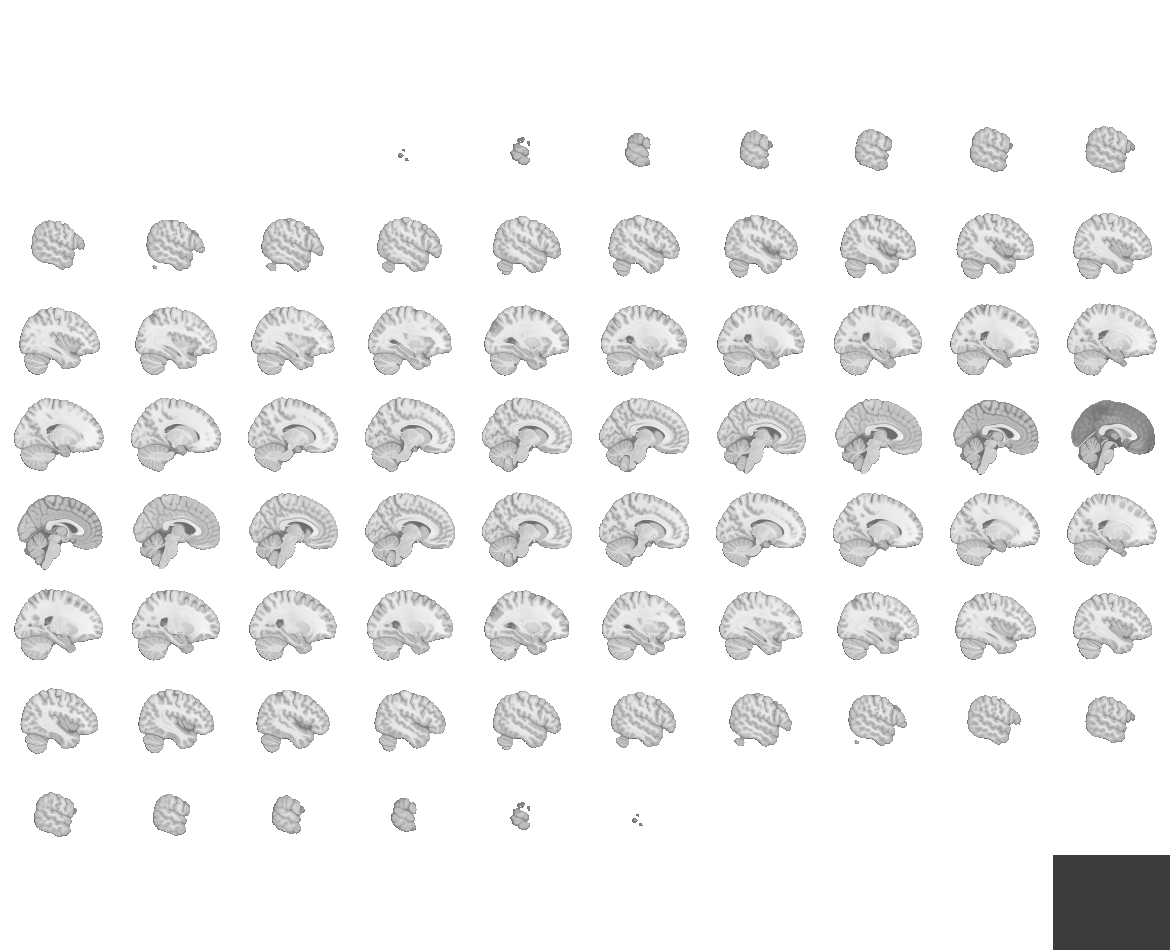
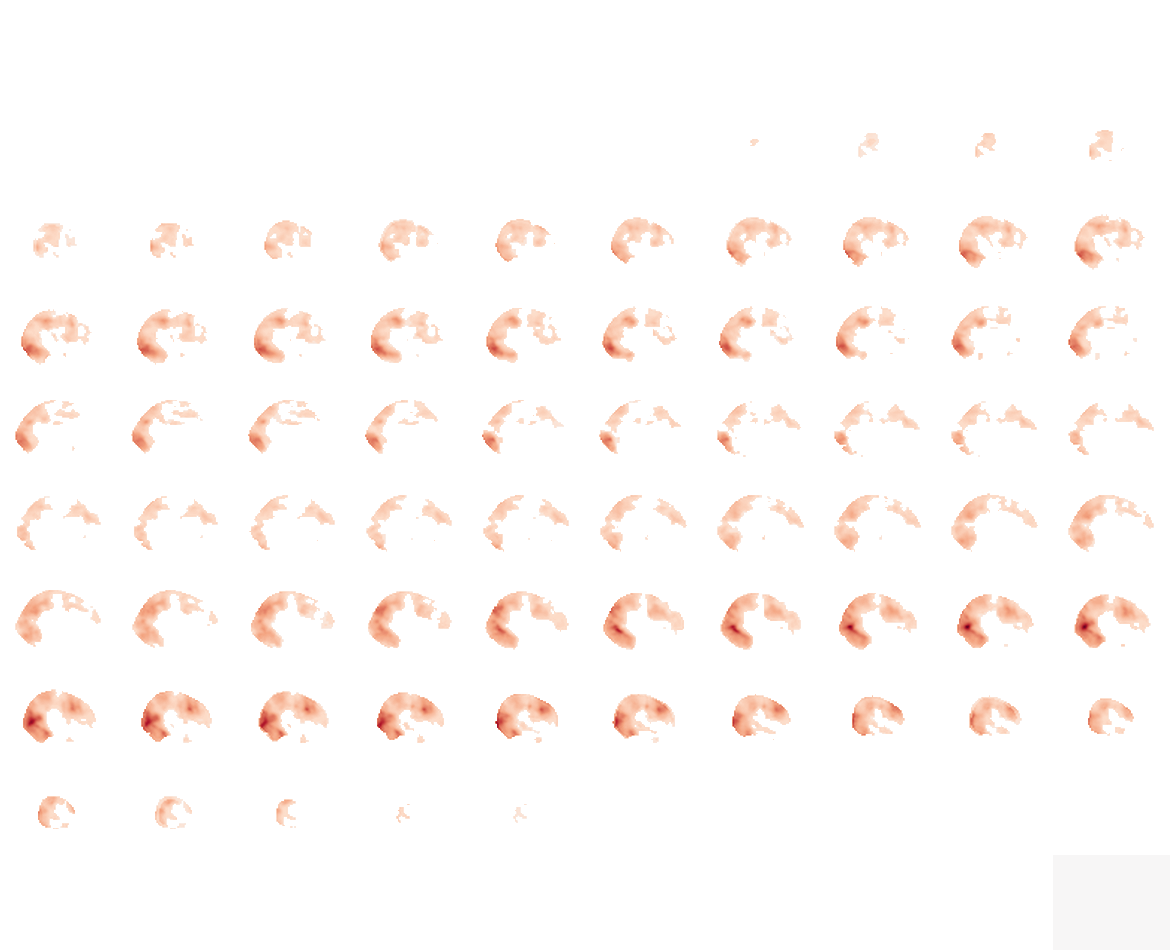

unpleasant_20



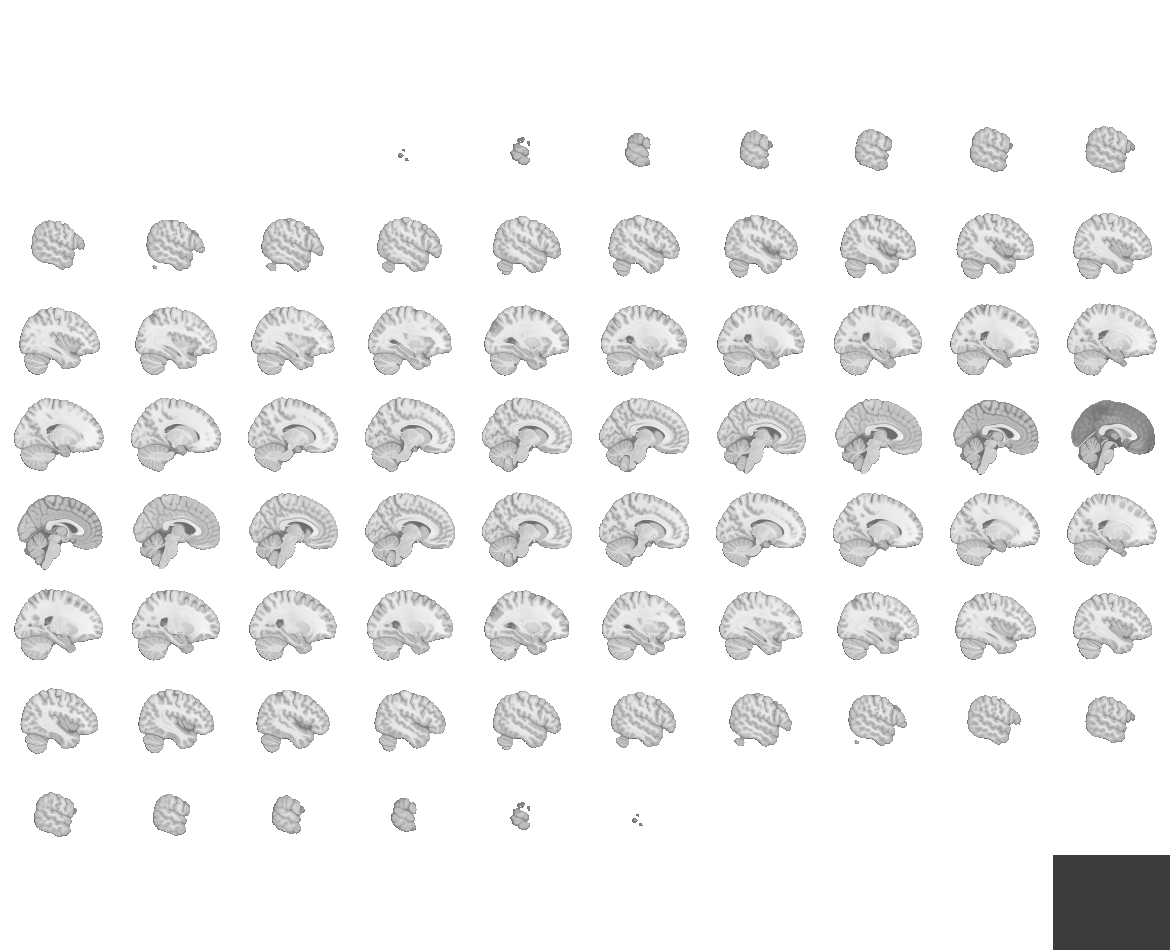
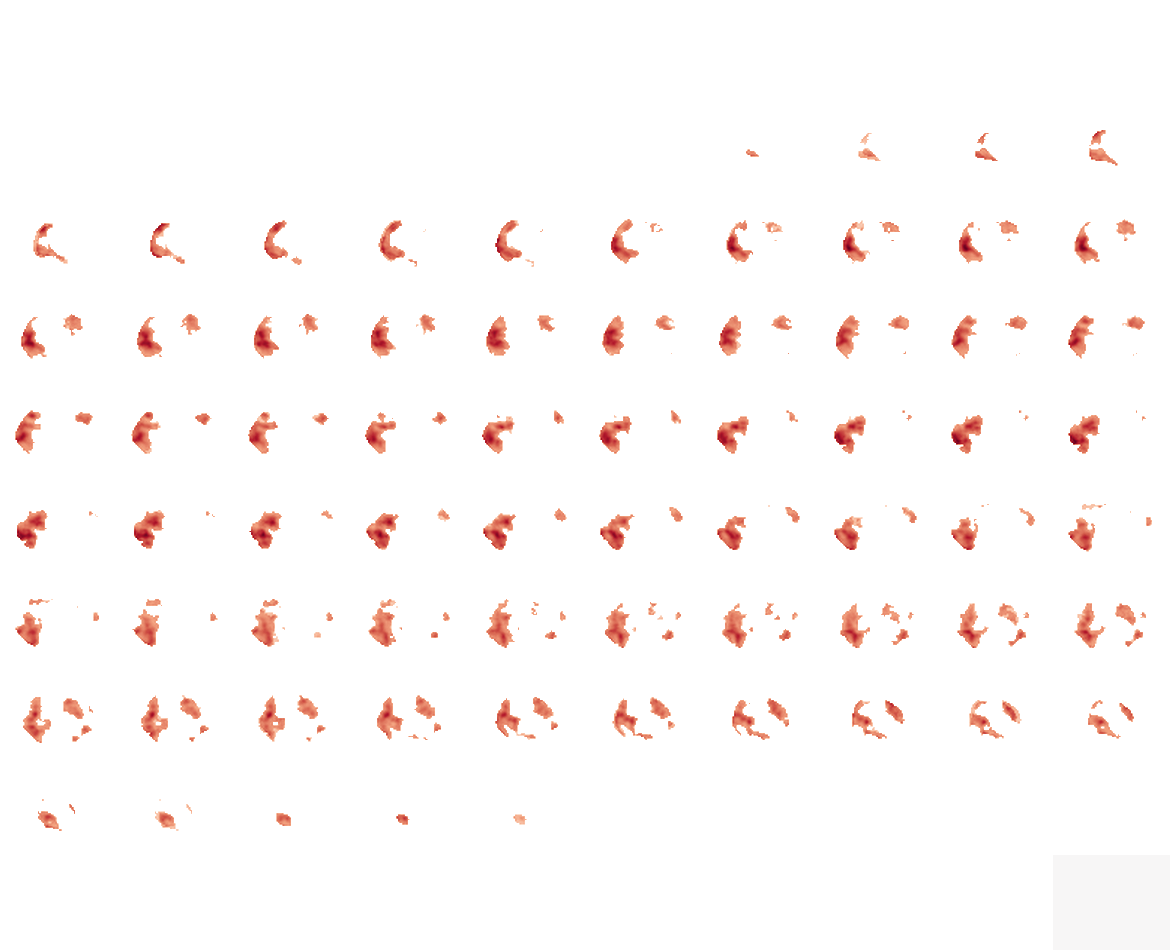

In [8]:
for row in summaries:
    print(row["case"])
    display(
        plotting.view_img(
            nib.load(row["output"]),
            draw_cross=False,
            black_bg=False,
            threshold=0,
            title=f"{row['case']} — signed FDR-significant t-values",
        )
    )